In [9]:
# utils.py - Python Utilities

# Libraries
import os
import requests
import tempfile
import glob
import numpy as np
import nibabel as nb
import nibabel as nib
import pandas as pd
import seaborn as sns
import networkx as nx

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from osfclient import OSF

from sklearn.linear_model import LinearRegression
from scipy.interpolate import griddata
from scipy.stats import spearmanr, pearsonr
from scipy.stats import ttest_ind
from statsmodels.nonparametric.smoothers_lowess import lowess

from brainspace.plotting import plot_hemispheres
from brainspace.mesh.mesh_io import read_surface
from brainspace.null_models import SpinPermutations

from brainstat.stats.terms import MixedEffect, FixedEffect
from brainstat.stats.SLM import SLM
from brainstat.datasets import fetch_mask, fetch_template_surface
from brainspace.datasets import load_mask

import cmocean
cmaps = cmocean.cm.cmap_d

In [4]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')
# Load fsLR 32k inflated
f32k_inf_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_inf_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')
mask_32k = load_mask(join=True)

# Boolean mask
#mask_surf = mask_5k != 0
mask_surf = mask_32k != 0

In [5]:
# -----------------------------------------------------------------------------
# FLIP data Right to Left
def flip_mat(mat_l, mat_r, lat_vec, flip='R'):
    '''
    Flips Right to Left data matrices to generate
    new matrices IPSILATERAL and CONTRALATERAL
    relative to the seizure onset

    Parameters
    ----------
    mat_l : numpy array
        Matrix with the values associated to the LEFT structures [subject x feature].
    mat_r     : numpy array
        Matrix with the values associated to the RIGHT structures [subject x feature].
    lat_vec   : numpy array (strings)
        Array with the laterality coded as R and L (rigth and left respectively).
    flip      : string
    Returns
    -------
    ipsi, ctra
    '''
    print("Flipping data from Right to Left")

    # Create an  array for the results
    ipsi = np.ndarray.copy(mat_l)
    ctra =  np.ndarray.copy(mat_r)

    for i, Lat in enumerate(lat_vec):
        if Lat == flip:
            ipsi[i,:] = mat_r[i,:]
            ctra[i,:] = mat_l[i,:]

    return ipsi, ctra

# -----------------------------------------------------------------------------
# Match data
def match_data(data_array, df_dat, col='preproc'):
    """
    Matches data based on a specified column in a dataframe.

    Parameters:
    - data_array (numpy.ndarray): Left dataset.
    - df_dat (pandas.DataFrame): Dataframe containing the data to be matched.
    - col (str, optional): Column name to use for matching. Default is 'preproc'.

    Returns:
    - data_array (numpy.ndarray): Left dataset after matching.
    - df (pandas.DataFrame): Dataframe after matching and dropping unmatched rows.

    """
    
    # Get the indices of rows with NaN values in the specified column
    nan_indices = df_dat.index[df_dat[col].isna()].values
    
    # Remove rows with NaN values in the specified column
    df_dat = df_dat.dropna(subset=[col])

    # Drop corresponding entries from the data array
    data_array = np.delete(data_array, nan_indices, axis=0)

    # Get the indices of unmatched rows
    indx = df_dat[df_dat[col] == 0].index.values[:]

    # Check if any subjects are unmatched
    N = np.isin(df_dat.index.values, indx)

    # Drop unmatched rows from the dataframe
    df = df_dat.drop(index=indx, axis=1)

    # Drop unmatched subjects from the data array
    data_array = data_array[np.where(N != True)]

    return data_array, df

# -----------------------------------------------------------------------------
# Plot the surface of patients and controls
def plot_ctx_groups(surf_lh, surf_rh, mtx, df, color_range=(-4,4), Save=False, Col="cmo.dense", png_file="", group=['Healthy', 'Patient'],
                   nan_color=(0, 0, 0, 1), mask=None, scale=2):
    """
    Plot the surface of patients and controls based on the given matrix and dataframe.
    Parameters:
    - mtx (numpy.ndarray): The matrix containing the data.
    - df (pandas.DataFrame): The dataframe containing the group information.
    - color_range (tuple, optional): The range of values for the color bar. Default is (-4, 4).
    - Str (str, optional): The label text for the groups. Default is 'feature'.
    - Save (bool, optional): Whether to save the plot as an image. Default is False.
    - Col (str, optional): The color map to use for the plot. Default is 'cmo.dense'.
    - png_file (str, optional): The file name for the saved image. Default is an empty string.

    Returns:
    - f: The plot object.

    """
    grad = [None] * len(group)

    # Add Groups to list of arrays
    for i, n in enumerate(group):
        grad[i] = np.mean(mtx[df.group==group[i],:], axis=0)
        if mask is not None:
            # Remove the midwall vertices
            grad[i][mask == False] = np.nan

    # Plot the surface PATIENTS and CONTROLS
    f = plot_hemispheres(surf_lh, surf_rh, array_name=grad, size=(900, 500),
                         color_bar='bottom', zoom=1.25, embed_nb=True,
                         interactive=False, share='both',
                         nan_color=nan_color, color_range=color_range,
                         cmap=Col, transparent_bg=True, label_text=group,
                         screenshot=Save, filename=png_file, scale=scale)
    return(f)

# -----------------------------------------------------------------------------
# Create a mixed effects model
def mem_groups(Data, df, Surf, Pcorr=["fdr", "rft"], Cthr=0.025, mask=None, mem=True, group=['Healthy', 'Patient']):
    '''
    Generate a mixed effects model of a Surface
    Contras: [TLE - Controls]

    Parameters
    ----------
    regex : str
        Regular expression with the path(s) to the data to be uploaded.

    Returns
    -------
    Array, pandas.Dataframe
     '''
    # -----------------------------------------------------------------------------
    # terms
    term_grp = FixedEffect(df['group'])
    term_age = FixedEffect(df['age'])
    term_sex = FixedEffect(df['sex'])
    term_subject = MixedEffect(df['participant_id'])

    # contrast  (Patient - Control)
    # 1: control, 2: patient
    contrast_grp = (df.group == group[1]).astype(int) - (df.group == group[0]).astype(int)

    # Model is is mixed Subject is set as random MIxed effect variable
    if mem == True:
        print("Y ~ group + age + sex + 1/subject")
        model = term_grp + term_sex + term_age  + term_subject
    else:
        model = term_grp + term_sex + term_age
        print("Y ~ group + age + sex")

    # fitting the model
    slm_mixed = SLM(
        model,
        contrast_grp,
        mask=mask,
        surf=Surf,
        correction=Pcorr,
        two_tailed=True,
        cluster_threshold=Cthr
    )
    slm_mixed.fit(Data)

    return slm_mixed

# -----------------------------------------------------------------------------
# Plot the results of the cortical SLM T-values
def plot_ctx_slm(surf_lh, surf_rh, slm, color_range=(-4,4), Str='slm', Save=False, Col="bwr", png_file='', mask=None, scale=2):
    '''
    Plots the results of cortical SLM
    MEM Y ~ Age + Sex + (1 | subject )
    '''

    # Mask od the midwall vertices
    if mask is not None:
        surf_data = slm.t[0]*mask
    else:
        surf_data = slm.t[0]

    # Plot t-values
    f = plot_hemispheres(surf_lh, surf_rh, array_name=surf_data, size=(900, 250), color_bar='bottom', zoom=1.25, embed_nb=True, interactive=False, share='both',
                             nan_color=(0, 0, 0, 1), cmap=Col, transparent_bg=True, label_text=[Str], color_range=color_range,
                             screenshot=Save, filename=png_file, scale=scale)
    return(f)

# -----------------------------------------------------------------------------
# Plot the results of the cortical SLM P-values
def plot_ctx_pval(surf_lh, surf_rh, slm, Str='slm', Save=False, Col="inferno", Thr=0.05, png_file='', scale=2):
    '''
    Plots the results of cortical SLM
    MEM Y ~ Age + Sex + (1 | subject )
    '''
    # Plot cluster p-values
    sig_pvalues = np.copy(slm.P["pval"]["C"])

    # Apply thresholding and create a new array with 0s and 1s
    plot_pvalues = np.where(sig_pvalues > Thr, 1, 0)

    f = plot_hemispheres(surf_lh, surf_rh, array_name=plot_pvalues, size=(900, 250), color_bar='bottom', zoom=1.25, embed_nb=True, interactive=False, share='both',
                             nan_color=(0, 0, 0, 1), cmap=Col, transparent_bg=True, label_text=[Str], color_range=(Thr, 1),
                             screenshot=Save, filename=png_file, scale=scale)
    return(f)

# -----------------------------------------------------------------------------
# Control Vertex data by thickness
def controlVertex(X,Y):
    '''
    controlVertex(X,Y)
    generates column wide residuals.
    Input matrices should be in [ N x vertices ]
    Same results as using R function: residuals(lm(y~x))

    Parameters
    ----------
    X : numpy.array
        Data matrix .
    Y : numpy.array
        Data matrix to be controlled by X (predict).

    Returns
    -------
    Array: Y_corr

    Usage
    -----
    Cortical MK6240~Thickness
    cmkth = controlVertex(X=cth, Y=cmk)
     '''

    if Y.shape != X.shape:
        print("X and Y matrices MUST have the same shape")
        raise ValueError("X and Y matrices MUST have the same shape")
    else:
        # Create an empty array for the results
        Y_corr=np.empty([Y.shape[0], Y.shape[1]])

        for i in range(0, Y.shape[1]):
            x = X[:,i].reshape(-1,1)
            y = Y[:,i].reshape(-1,1)

            # Create linear regression object
            mod = LinearRegression()
            # Fit the data to the model
            slm = mod.fit(x, y)
            # Generate the predicte values
            predic = slm.predict(x)
            # predic = (np.dot(x, slm.coef_) + slm.intercept_) == slm.predict(x)

            # Residual
            residual = (y - predic)

            # Save the corrected Y matrix
            Y_corr[:,i] = residual[:,0]

        return Y_corr

# -----------------------------------------------------------------------------
def plot_connectome(mtx, Title='matrix plot', xlab='X', ylab='Y', col='rocket', vmin=None, vmax=None,
                   xticklabels='auto', yticklabels='auto',xrot=90, yrot=0, save_path=None, figsize=(15,10)):

    '''
    This optional function, only plots a connectome as a heatmap
    Parameters
    ----------
    mtx : np.array
    Returns
    -------
    '''
    f, ax = plt.subplots(figsize=(figsize))
    g = sns.heatmap(mtx, ax=ax, cmap=col, vmin=vmin, vmax=vmax, xticklabels=xticklabels, yticklabels=yticklabels)
    g.set_xlabel(xlab)
    g.set_ylabel(ylab)
    g.set_title(Title)
    # Rotate the x-axis labels
    # rotate tick labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=xrot, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=yrot, ha='right')

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    pass

def plot_ridgeplot(matrix, matrix_df=None, Cmap='rocket', Range=(0.5, 2), Xlab="SUVR value", save_path=None, 
                  title=None, Vline=None, VlineCol='darkred'):
    """
    Parameters:
    - matrix: numpy array
        The matrix to be plotted.
    - matrix_df: pandas DataFrame, optional
        The DataFrame containing additional information about the matrix.
    - Cmap: str, optional
        The colormap to be used for the ridgeplot. Default is 'rocket'.
    - Range: tuple, optional
        The range of values for the x-axis. Default is (0.5, 2).
    - Xlab: str, optional
        The label for the x-axis. Default is "SUVR value".
    - save_path: str, optional
        The file path to save the plot. If not provided, the plot will be displayed.
    - title: str, optional
        The title of the plot.
    - Vline: float, optional
        Whether to plot the mean line for all distributions. Default is False.
    Returns:
    None

    Plot a ridgeplot of the given matrix.
    
    """
    if matrix_df is None:
        # Create a default DataFrame with placeholder values
        matrix_df = pd.DataFrame({'id': [f'{i+1}' for i in range(matrix.shape[0])]})
        print_labels = False
    else:
        print_labels = True

    mean_row_values = np.mean(matrix, axis=1)
    sorted_indices = np.argsort(mean_row_values)
    sorted_matrix = matrix[sorted_indices]
    sorted_id_x = matrix_df['id'].values[sorted_indices]

    ai = sorted_matrix.flatten()
    subject = np.array([])
    id_x = np.array([])

    for i in range(sorted_matrix.shape[0]):
        label = np.array([str(i+1) for j in range(sorted_matrix.shape[1])])
        subject = np.concatenate((subject, label))
        id_label = np.array([sorted_id_x[i] for j in range(sorted_matrix.shape[1])])
        id_x = np.concatenate((id_x, id_label))

    d = {'feature': ai,
         'subject': subject,
         'id_x': id_x
        }
    df = pd.DataFrame(d)

    f, axs = plt.subplots(nrows=sorted_matrix.shape[0], figsize=(3.468504*2.5, 2.220472*3.5), sharex=True, sharey=True)
    f.set_facecolor('none')

    x = np.linspace(Range[0], Range[1], 100)

    for i, ax in enumerate(axs, 1):
        sns.kdeplot(df[df["subject"]==str(i)]['feature'],
                    fill=True,
                    color="w",
                    alpha=0.25,
                    linewidth=1.5,
                    legend=False,
                    ax=ax)
        
        ax.set_xlim(Range[0], Range[1])
        
        im = ax.imshow(np.vstack([x, x]),
                       cmap=Cmap,
                       aspect="auto",
                       extent=[*ax.get_xlim(), *ax.get_ylim()]
                      )
        ax.collections
        path = ax.collections[0].get_paths()[0]
        patch = mpl.patches.PathPatch(path, transform=ax.transData)
        im.set_clip_path(patch)
           
        ax.spines[['left','right','bottom','top']].set_visible(False)
        
        if i != sorted_matrix.shape[0]:
            ax.tick_params(axis="x", length=0)
        else:
            ax.set_xlabel(Xlab)
            
        ax.set_yticks([])
        ax.set_ylabel("")
        
        ax.axhline(0, color="black")

        ax.set_facecolor("none")

    for i, ax in enumerate(axs):
        if i == sorted_matrix.shape[0] - 1:
            ax.set_xticks([Range[0], Range[1]])  # Set x-axis ticks for the bottom plot
        else:
            ax.set_xticks([])  # Remove x-axis ticks from other plots
        if print_labels:
            ax.text(0.05, 0.01, sorted_id_x[i], transform=ax.transAxes, fontsize=10, color='black', ha='left', va='bottom')

    # Calculate and add a single mean line for all subplots if mean_line is True
    if Vline is not None:
        # Check that Vline is numeric
        for ax in axs:
            ax.axvline(x=Vline, linestyle='dashed', color=VlineCol)

    plt.subplots_adjust(hspace=-0.8)
    
    if title:
        plt.suptitle(title, y=0.99, fontsize=16)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    else:
        plt.show()

def load_data(regex, surf='fslr32k'):
    '''
    load_hippdata(regex,)
    Loads a subject(s) using a path OR regular expression.

    Parameters
    ----------
    regex : str
        Regular expression with the path(s) to the data to be uploaded.
    surf  : str
        ['hippunfold', 'fslr32k', 'fs5']
    Returns
    -------
    tuple
        - numpy.ndarray: Array of loaded data
        - pandas.DataFrame: DataFrame of patient data
    '''
    # get the data
    files = sorted(glob.glob(regex))

    # Empty variable to load the data
    if surf == 'fslr32k':
        N = 32492
    elif surf == 'hippunfold':
        N = 7262
    else:
        raise ValueError("Unsupported surface type. Choose from ['hippunfold', 'fslr32k', 'fs5']")

    def load_fun(file):
        mat = nib.load(file).darrays[0].data
        return mat

    # load the data
    vx_val = np.empty([N,])  # Initialize with N rows
    for n, file in enumerate(files):
        vx_val = np.vstack((vx_val, load_fun(file)))

    vx_val = np.delete(vx_val, (0), axis=0)  # Remove the first empty row

    # Generate a dataframe of patients and controls
    data_tb = {
        'sub': [x.split('/')[-1].split('_')[0].split('sub-')[1] for x in files],
        'type': [x.split('/')[-1].split('_')[0].split('sub-')[1][0] for x in files],
        'ses': [x.split('/')[-1].split('_')[1].split('ses-')[1][1] for x in files],
        'id': [x.split('/')[-1].split('_')[0].split('sub-')[1] for x in files]
    }
    data_df = pd.DataFrame(data_tb)

    # Merge Subject ID and Session to obtain 'id'
    data_df['id'] = data_df[['sub', 'ses']].agg('_0'.join, axis=1)

    # Use the id as row Index
    data_df.index = data_df['id']

    return vx_val, data_df

# -----------------------------------------------------------------------------
# Function to generate the surface models of mk6240 vs Clinical and behavioral variables

def slm_surf(df, Y, feat='age', neg_tail=False, cthr=0.05, alpha=0.3, scale=2, color_range=(-3, 3), nan_color=(0, 0, 0, 1),
             Save=False, png_file=''):
    """
    Run SLM analysis on surface data to examine relationships between cortical features and clinical/behavioral variables.
    
    This function fits a mixed-effects model to surface data, identifying brain regions where the specified 
    feature shows significant associations. The analysis includes statistical thresholding and visualization.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe containing clinical/behavioral variables and participant identifiers.
        Must include columns for 'feat' and 'participant_id'.
    Y : numpy.ndarray
        Surface data array with shape (n_subjects, n_vertices) to fit the model on.
    feat : str, optional
        Column name in df representing the feature to analyze (default: 'age').
    neg_tail : bool, optional
        If True, reverses the contrast direction for the analysis (default: False).
    cthr : float, optional
        Cluster-forming threshold for multiple comparison correction (default: 0.05).
    alpha : float, optional
        Transparency level for non-significant regions in visualization (default: 0.3).
    scale : int, optional
        Scaling factor for the output figure size (default: 2).
    color_range : tuple, optional
        Min and max values for the color scale (default: (-3, 3)).
    nan_color : tuple, optional
        RGBA color for NaN/masked regions (default: (0, 0, 0, 1)).
    Save : bool, optional
        Whether to save the output figure (default: False).
    png_file : str, optional
        Filepath for saving the figure if Save=True (default: '').
    
    Returns:
    --------
    matplotlib.figure.Figure
        Brain surface visualization with statistical results overlaid.
    
    Notes:
    ------
    - Uses mixed-effects model: Y ~ feature + (1|participant_id)
    - Applies RFT correction for multiple comparisons
    - Removes NaN values from both df and Y before fitting
    - Requires fsLR-32k surface templates
    
    Example:
    --------
    >>> fig = slm_surf(df, cortical_data, feat='disease_duration', 
    ...                neg_tail=False, cthr=0.01, Save=True, 
    ...                png_file='disease_duration_results.png')
    """
    
    # Load fsLR-32k surface
    surf_lh = fetch_surface('fsLR-32k.L.surf.gii')
    surf_rh = fetch_surface('fsLR-32k.R.surf.gii')
    fslr32k = fetch_template_surface("fslr32k", join=True)

    # fsLR-32k middle wall mask
    fslr32k_mask = fetch_mask("fslr32k")

    # Identify NaN indices in the feature column
    nan_idx = df[feat].isna()

    # Remove NaN rows from df and Y
    df_clean = df.loc[~nan_idx].copy()
    Y_clean = Y[~nan_idx]  # Assuming Y has the same length as df

    # Define fixed and mixed effects models
    term = FixedEffect(df_clean[feat])
    term_subject = MixedEffect(df_clean['participant_id'])
    
    # Set contrast direction and colormap based on neg_tail flag
    contrast = -df_clean[feat] if neg_tail else df_clean[feat]
    cmap = "RdBu" if neg_tail else "RdBu_r"
    
    # Define the full model
    model = term + term_subject
    
    # Run SLM analysis with the given parameters
    slm_feat = SLM(
        model,
        contrast,
        surf=fslr32k,
        mask=fslr32k_mask,
        correction="rft",
        cluster_threshold=cthr,
        two_tailed=False
    )
    slm_feat.fit(Y_clean)
    
    # Get the cluster p-values from the analysis
    sig_pvalues = np.copy(slm_feat.P["pval"]["C"])
    
    # Apply thresholding to create a binary mask of significant values
    surf_pvalues = np.where(sig_pvalues > cthr, alpha, 1)
    
    # Multiply the t-values by the mask and thresholded p-values
    surf_data = slm_feat.t[0] * fslr32k_mask * surf_pvalues
    
    # Ensure negative values are set to zero
    surf_data[surf_data < 0] = 0
    
    # Plot the results on brain hemispheres
    f = plot_hemispheres(
        surf_lh, surf_rh, array_name=surf_data, size=(900, 250), color_bar='bottom', 
        zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=nan_color, 
        cmap=cmap, transparent_bg=True, label_text=[feat], color_range=color_range, 
        screenshot=Save, scale=scale, filename=png_file
    )

    return f

def fetch_surface(surf_name='fsLR-5k.L.inflated.surf.gii', is_surf=True, nibabel=False):

        """
        Fetches a GIFTI surface file from the micapipe GitHub repository.

        Args:
            surf_name (str): The name of the surface file to download (default is 'fsLR-5k.L.inflated.surf.gii').

        Returns:
            nibabel.Giftidata: The loaded surface data from the GIFTI file.
        """

        # Construct the URL for the surface file on GitHub
        url = f'https://raw.githubusercontent.com/MICA-MNI/micapipe/refs/heads/master/surfaces/{surf_name}'

        # Step 1: Download the surface file from the URL
        response = requests.get(url)

        # Ensure the request was successful
        if response.status_code != 200:
            raise Exception(f"Failed to download the surface file: {surf_name} (Status code: {response.status_code})")

        # Step 2: Save the downloaded file in a temporary directory
        with tempfile.NamedTemporaryFile(delete=False, suffix='.surf.gii') as temp_file:
            temp_file.write(response.content)
            temp_file_name = temp_file.name  # Get the temporary file name

        # Step 3: Read the surface data from the downloaded file (assuming GIFTI format)
        if is_surf:
            if nibabel:
                surf_data = nib.load(temp_file_name)
            else:
                surf_data = read_surface(temp_file_name, itype='gii')
        else:
            surf_data = nib.load(temp_file_name).darrays[0].data

        # Step 4: Remove the temporary file after reading (to avoid cluttering disk)
        os.remove(temp_file_name)

        # Return the surface data
        return surf_data


def metric_resample(s32k_metric):
    # Split the metric in L and R
    s32k_metric_L = s32k_metric[0:32492]
    s32k_metric_R = s32k_metric[32492:64984]
    
    # Initialize lists to store resampled metrics
    s5k_metric_L = []
    s5k_metric_R = []
    
    for hemi in ['L', 'R']:
        # Load the fsLR-32k surface
        s32k_surf = fetch_surface(f'fsLR-32k.{hemi}.inflated.surf.gii', nibabel=True)
        s32k_coords = s32k_surf.darrays[0].data
        
        # Load the low-resolution surface (s5k)
        s5k_surf = fetch_surface(f'fsLR-5k.{hemi}.inflated.surf.gii', nibabel=True) 
        s5k_coords = s5k_surf.darrays[0].data
        
        # Interpolate the metric data from s32k to s5k
        if hemi == 'L':
            s5k_metric_L = griddata(s32k_coords, s32k_metric_L, s5k_coords, method='nearest')
        else:
            s5k_metric_R = griddata(s32k_coords, s32k_metric_R, s5k_coords, method='nearest')
    
    # Concatenate the data
    s5k_metric = np.concatenate((s5k_metric_L, s5k_metric_R), axis=0)
    
    return s5k_metric

def rescale(vector, min_val=0, max_val=100):
    """
    Rescales a vector to a specified range [min_val, max_val].

    Parameters:
    - vector (array-like): The input data to rescale.
    - min_val (float): The minimum value of the rescaled range. Default is 0.
    - max_val (float): The maximum value of the rescaled range. Default is 100.

    Returns:
    - numpy.ndarray: The rescaled vector.
    """
    # Convert to numpy array for calculations
    vector = np.array(vector)
    
    # Handle NaN values by ignoring them in min and max calculations
    min_vector = np.nanmin(vector)
    max_vector = np.nanmax(vector)
    
    # Apply the rescaling formula, ignoring NaNs
    rescaled_vector = min_val + (vector - min_vector) * (max_val - min_val) / (max_vector - min_vector)
    
    return rescaled_vector

def plot_brain_network(surf_lh, surf_rh, mask_5k, adj_matrix, node_val=None, node_colmap='bone_r',
                      edge_alpha=0.35, sparcity=0.99, node_colrange = None, node_sizes=None, save_path=None,
                      dpi=300, figsize=(42, 12)):
    """
    Plots the left and right hemispheres of a brain network based on the provided surface coordinates and adjacency matrix.

    Parameters:
    - surf_lh: Surface object for the left hemisphere. Must have a 'points' attribute containing the coordinates.
    - surf_rh: Surface object for the right hemisphere. Must have a 'points' attribute containing the coordinates.
    - adj_matrix: Adjacency matrix representing the brain network. NaN values will be replaced with 0.
    - node_val: Optional. Array of node values for coloring the nodes. If not provided, the mean of the adjacency matrix will be used.
    - node_colmap: Optional. Colormap for the nodes. Default is 'bone_r'.

    The function will plot the left and right hemispheres in a 1x2 layout and add a colorbar for the node values.
    """
    
    # Get the lenght of the mask_5k
    N = int(mask_5k.shape[0])
    M = int(N/2)
    
    # Split the brain mask into left and right
    mask_5k_L = mask_5k[0:M]
    mask_5k_R = mask_5k[M:N]
        
    # Create an array of coordinates
    fslr5k_coord_L = surf_lh.points
    fslr5k_coord_R = surf_rh.points

    # Remove the middle wall coordinates
    fslr5k_coord_L = fslr5k_coord_L[mask_5k_L, :]
    fslr5k_coord_R = fslr5k_coord_R[mask_5k_R, :]

    # Transform the coordinates
    # Right Hemisphere
    # x-axis: anterior to posterior (original y-axis)
    # y-axis: inferior to superior (original z-axis)
    # z-axis: left to right (original x-axis)
    transformed_coord_R = fslr5k_coord_R[:, [1, 2, 0]]

    # Left Hemisphere
    # x-axis: posterior to anterior (original y-axis, flipped)
    # y-axis: inferior to superior (original z-axis)
    # z-axis: right to left (original x-axis, flipped)
    transformed_coord_L = fslr5k_coord_L[:, [1, 2, 0]]
    transformed_coord_L[:, [0, 2]] = -transformed_coord_L[:, [0, 2]]

    # Use only the first two dimensions for plotting
    plot_coord_R = transformed_coord_R[:, :2]
    plot_coord_L = transformed_coord_L[:, :2]

    # Replace NaN values in the adjacency matrix with 0
    A = adj_matrix
    A[np.isnan(A)] = 0
    
    # Threshold based on the edges
    A_edges = A[np.tril_indices_from(A, k=-1)]
    threshold = np.quantile(A_edges, sparcity)
    
    # Get the Left and the Right adjacency matrices
    A_L = A[0:M, 0:M]
    A_R = A[M:N, M:N]
    
    # Slice the left Adjacency matrix to remove the midwall
    A_L_NO_midwall = A_L[mask_5k_L, :]
    A_L_NO_midwall = A_L_NO_midwall[:, mask_5k_L]
    
    # Slice the Right Adjacency matrix to remove the midwall
    A_R_NO_midwall = A_R[mask_5k_R, :]
    A_R_NO_midwall = A_R_NO_midwall[:, mask_5k_R]

    # Create a weighted graph network object with networkx from the adjacency matrix
    G_L = nx.from_numpy_array(A_L_NO_midwall)
    G_R = nx.from_numpy_array(A_R_NO_midwall)

    # Get the coordinates of each node
    pos_R = {i: plot_coord_R[i] for i in range(len(plot_coord_R))}
    pos_L = {i: plot_coord_L[i] for i in range(len(plot_coord_L))}

    # Get EDGE values for the Left Hemisphere
    edges_L = G_L.edges(data=True)
    weights_L = [d['weight'] for (u, v, d) in edges_L if not np.isnan(d['weight'])]
    edges_thr_L = [(u, v, d) for (u, v, d) in edges_L if d['weight'] >= threshold]

    # Get EDGE values for the Right Hemisphere
    edges_R = G_R.edges(data=True)
    weights_R = [d['weight'] for (u, v, d) in edges_R if not np.isnan(d['weight'])]
    edges_thr_R = [(u, v, d) for (u, v, d) in edges_R if d['weight'] >= threshold]
    
    # If the node values are not set, calculate the mean ignoring the NaN values
    if node_val is None:
        node_val = np.nanmean(adj_matrix, axis=0)

    # Node size
    if node_sizes is None:
        node_sizes = node_val
        node_sizes_L = rescale(node_sizes[0:M],0,100)
        node_sizes_R = rescale(node_sizes[M:N],0,100)
    else:
        node_sizes_L = node_sizes[0:M]
        node_sizes_R = node_sizes[M:N]
        
    # Node color range
    if node_colrange is None:
        node_colrange = (np.nanquantile(node_val, 0.01), np.nanquantile(node_val, 0.99))
        
    # ---------------------------------------------
    # In a layout of 1x2 plot the pos_L, pos_R then the colorbar
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Rescale edge weights for Left Hemisphere
    w_L = np.array([d['weight'] for (u, v, d) in edges_thr_L])
    w_L = rescale(w_L, 0, 1)

    # LEFT nodes
    node_val_L = node_val[0:M]

    # Plot right network
    nx.draw_networkx_nodes(G_L, pos_L, node_color=node_val_L[mask_5k_L], cmap=node_colmap, 
                           node_size=node_sizes_L[mask_5k_L], vmin=node_colrange[0], vmax=node_colrange[1], ax=axes[0])
    nx.draw_networkx_edges(G_L, pos_L, edgelist=edges_thr_L, alpha=edge_alpha, edge_color='gray', width=w_L.tolist(), ax=axes[0])
    axes[0].grid(False)
    axes[0].set_title('Left Hemisphere')
    axes[0].axis('off')

    # Rescale edge weights for Right Hemisphere
    w_R = np.array([d['weight'] for (u, v, d) in edges_thr_R])
    w_R = rescale(w_R, 0, 1)
    
    # RIGHT nodes
    node_val_R = node_val[M:N]

    # Plot left network
    nx.draw_networkx_nodes(G_R, pos_R, node_color=node_val_R[mask_5k_R], cmap=node_colmap, 
                           node_size=node_sizes_R[mask_5k_R], vmin=node_colrange[0], vmax=node_colrange[1], ax=axes[1])
    nx.draw_networkx_edges(G_R, pos_R, edgelist=edges_thr_R, alpha=edge_alpha, edge_color='gray', width=w_R.tolist(), ax=axes[1])
    axes[1].grid(False)
    axes[1].set_title('Right Hemisphere')
    axes[1].axis('off')

    # Add colorbar for nodes
    sm = ScalarMappable(cmap=node_colmap, norm=Normalize(vmin=node_colrange[0], vmax=node_colrange[1]))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes, orientation='vertical')
    cbar.set_label('Node Value')
    
    # Save the figure with high resolution
    if save_path is not None:
        plt.savefig(save_path, dpi=dpi)

def map_to_labels5k(fslr5k_masked, mask):
    
    # Get the index of the non medial wall regions
    mask_indx = np.where(mask==1)[0]
    
    # map to the labels
    labels_5k = np.full(mask.shape, np.nan)
    labels_5k[mask_indx] = fslr5k_masked
    
    return(labels_5k)

def plot_network_correlation(Xval, Yval, Xnames=['X1', 'X2'],
                             Ylab='mk6240 tval', Xlab='Mean Connectivity', col='RdBu_r', 
                              linecol='darkred', barlab='Group difference mk6240 tval'):
    # Create a 1x2 layout for the plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Define the colormap normalization centered at zero
    norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=6)

    # First plot
    correlation, p_value = spearmanr(Xval[0], Yval)
    scatter_fc = sns.scatterplot(x=Xval[0], y= Yval, ax=axes[0], 
                                 hue=Yval, palette=col, alpha=0.5, legend=None, hue_norm=norm)
    lowess_fc = lowess(Yval, Xval[0], frac=0.3)
    axes[0].plot(lowess_fc[:, 0], lowess_fc[:, 1], color='darkred', alpha=0.95)
    axes[0].set_title(f'{Xnames[0]}\nrho: {correlation:.2f}\npval: {p_value:.8f}')
    axes[0].set_xlabel(Xlab)
    axes[0].set_ylabel(Ylab)

    # Second plot: sc_5k_Colmean vs mk6240_tval_map_5k
    correlation, p_value = spearmanr(Xval[1], Yval)
    scatter_sc = sns.scatterplot(x=Xval[1], y=Yval, ax=axes[1], 
                                 hue=Yval, palette=col, alpha=0.5, legend=None, hue_norm=norm)
    lowess_sc = lowess(Yval, Xval[1], frac=0.3)
    axes[1].plot(lowess_sc[:, 0], lowess_sc[:, 1], color=linecol, alpha=0.95)
    axes[1].set_title(f'{Xnames[1]}\nrho: {correlation:.2f}\npval: {p_value:.8f}')
    axes[1].set_xlabel(Xlab)
    axes[1].set_ylabel(Ylab)

    # Add colorbar outside the plot area
    divider = make_axes_locatable(axes[1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    sm = plt.cm.ScalarMappable(cmap=col, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label=barlab)

    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()

def plot_network_spintest(Xval, Yval, sp, fslr5k_mask, Xnames=['X1', 'X2']):
    # Number of vertice of fslr5k
    N5k=9684

    # Map the results to the fsLR-5k surface
    Xval1_lh = Xval[0][0:int(N5k/2)]
    Xval1_rh = Xval[0][int(N5k/2):N5k]

    Xval2_lh = Xval[1][0:int(N5k/2)]
    Xval2_rh = Xval[1][int(N5k/2):N5k]

    # Get the rotated data
    Xval1_rotated = np.hstack(sp.randomize(Xval1_lh, Xval1_rh))
    Xval2_rotated = np.hstack(sp.randomize(Xval2_lh, Xval2_rh))

    # Plot null distribution
    fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))

    feats = {Xnames[1]: Xval[1], Xnames[0]: Xval[0]}
    rotated = {Xnames[1]: Xval2_rotated, Xnames[0]: Xval1_rotated}

    r_spin = np.empty(sp.n_rep)

    for k, (fn, feat) in enumerate(feats.items()):
        r_obs, pv_obs = spearmanr(feat[fslr5k_mask], Yval[fslr5k_mask])

        # Compute perm pval
        for i, perm in enumerate(rotated[fn]):
            mask_rot = fslr5k_mask & ~np.isnan(perm)  # Remove midline
            r_spin[i] = spearmanr(perm[mask_rot], Yval[mask_rot])[0]
        pv_spin = np.mean(np.abs(r_spin) >= np.abs(r_obs))

        # Plot null dist
        axs[k].hist(r_spin, bins=25, density=True, alpha=0.5, color=(.8, .8, .8))
        axs[k].axvline(r_obs, lw=2, ls='--', color='k')
        axs[k].set_xlabel(f'Correlation with {fn}')
        if k == 0:
            axs[k].set_ylabel('Density')

        print(f'{fn.capitalize()}:\n r: {r_obs:.3f}\n Obs : {pv_obs:.5e}\n Spin: {pv_spin:.3f}\n')

    fig.tight_layout()
    plt.show()

def neighborhood_estimates(nodal_measurements, connectivity_matrix, method='pearson'):
    N = len(nodal_measurements)
    
    # Set the diagonal to NaN to exclude self-connections
    np.fill_diagonal(connectivity_matrix, np.nan)
    
    # Initialize matrix to store the estimates for neighbors
    nodal_neighbors = np.zeros(N)

    for i in range(N):
        # Connected neighbors excluding NaN values
        connected_neighbors = np.where(~np.isnan(connectivity_matrix[i, :]))[0]
        Ni_neighbors = len(connected_neighbors)  # Only consider connected nodes excluding NaN
        
        if Ni_neighbors > 0:  # Ensure there are neighbors to consider
            weights = connectivity_matrix[i, connected_neighbors]
            nodal_neighbors[i] = np.nanmean(nodal_measurements[connected_neighbors] * weights)

    # Calculate correlation coefficients
    if method == 'spearman':
        correlation_neighbors, _ = spearmanr(nodal_measurements, nodal_neighbors)
    else:  # Default to Pearson
        correlation_neighbors, _ = pearsonr(nodal_measurements, nodal_neighbors)

    return correlation_neighbors, nodal_neighbors
 
def osf_download(name: str, project_id: str) -> str:
    """
    Download a file from an OSF project to a temporary location and return the file path.
    
    Parameters:
    - name (str): The name of the file to download.
    - project_id (str): The OSF project ID.
    
    Returns:
    - str: The path of the downloaded file.
    """
    # Initialize OSF client
    osf = OSF()

    # Retrieve the project
    project = osf.project(project_id)

    # Get the default storage (osfstorage)
    storage = project.storage('osfstorage')

    # List all files and filter by name
    file_ = next((f for f in storage.files if f.name == name), None)

    if file_:
        print(f"Found file: {file_.name}")
        
        # Create a temporary directory
        temp_dir = tempfile.mkdtemp()

        # Define the local path to store the file
        local_path = os.path.join(temp_dir, file_.name)

        # Download the file to the temporary directory
        with open(local_path, 'wb') as local_file:
            file_.write_to(local_file)
            print(f"Downloaded {file_.name} to {local_path}")

        # Return the path of the downloaded file
        return local_path
    else:
        raise FileNotFoundError(f"File '{name}' not found in the project.")

def fetch_annot(atlas, surf='fsaverage5'):
    '''
      Fetches the annotation labels for a specific brain parcellation and generates a medial wall mask.

      Parameters:
      -----------
      atlas : str
        The name of the brain parcellation atlas to fetch (e.g., 'glasser-360', 'aparc-a2009s').
      surf : str, optional
        The surface space to use for the parcellation. Default is 'fsaverage5'.
        Options:
        - 'fsaverage5': Uses FreeSurfer's fsaverage5 surface space.
        - 'fsLR-32k': Uses fsLR-32k surface space.

      Returns:
      --------
      labels : numpy.ndarray
        An array of labels corresponding to the parcellation, with medial wall regions set to 0.
      mask : numpy.ndarray
        A boolean mask indicating non-medial wall regions (True for valid regions, False for medial wall).
      Ndim : int
        The number of unique labels in the parcellation.

      Notes:
      ------
      - The function downloads the required annotation files from a GitHub repository.
      - For 'fsaverage5', it processes both left and right hemisphere annotation files.
      - For 'fsLR-32k', it reads the labels from a CSV file.
      - Medial wall regions are excluded from the mask.
      - For the 'aparc-a2009s' atlas on 'fsaverage5', specific medial wall labels (lh=42, rh=117) are excluded.

      Raises:
      -------
      Exception
        If the annotation file cannot be downloaded or the request fails.

      Example:
      --------
      labels, mask, Ndim = fetch_annot('glasser-360', surf='fsaverage5')
    '''

    # Construct the URL for the surface file on GitHub
    url = f'https://github.com/MICA-MNI/micapipe/raw/refs/heads/master/parcellations'
      
    def download_atlas(url_to_file):
      # Download the surface file from the URL
      response = requests.get(url_to_file)

      # Ensure the request was successful
      if response.status_code != 200:
        raise Exception(f"Failed to download the {atlas} atlas on {surf} (Status code: {response.status_code})\n{url_to_file}")

      # Step 2: Save the downloaded file in a temporary directory
      with tempfile.NamedTemporaryFile(delete=False) as temp_file:
        temp_file.write(response.content)
        temp_file_name = temp_file.name  # Get the temporary file name
      
      return(temp_file_name)
    
    if surf == 'fsaverage5':
        # Load LEFT annotation file in fsaverage5
        tmp_file  = download_atlas(f'{url}/lh.{atlas}_mics.annot')
        annot_lh_fs5= nib.freesurfer.read_annot(tmp_file)
        os.remove(tmp_file)

        # Unique number of labels of a given atlas
        Ndim = max(np.unique(annot_lh_fs5[0]))

        # Load RIGHT annotation file in fsaverage5
        tmp_file  = download_atlas(f'{url}/rh.{atlas}_mics.annot')
        print(tmp_file)
        annot_rh_fs5 = nib.freesurfer.read_annot(tmp_file)[0]+Ndim
        os.remove(tmp_file)

        # replace with 0 the medial wall of the right labels
        annot_rh_fs5 = np.where(annot_rh_fs5==Ndim, 0, annot_rh_fs5) 

        # fsaverage5 labels
        labels = np.concatenate((annot_lh_fs5[0], annot_rh_fs5), axis=0)
    
    else:
        # Read label for fsLR-32k
        tmp_file  = download_atlas(f'{url}/{atlas}_conte69.csv')
        labels = np.loadtxt(open(tmp_file), dtype=int)
        os.remove(tmp_file)

    # mask of the medial wall
    mask = labels != 0
    
    # Midwall labels of aparc-a2009s are lh=42 and rh=117
    if atlas == 'aparc-a2009s' and surf == 'fsaverage5':
        mask[(labels == 117) | (labels == 42)] = 0
    
    #print(f'{atlas}; midwall = {Ndim}, length = {str(labels.shape)}')
    
    return(labels, mask, Ndim)

def plot_mk6240_group_summary(slm, mk_matched, df, threshold=0.01, ylim=[0.7, 1.7]):
    df = df.copy()  # avoid SettingWithCopyWarning

    # Copy p-values and define hemispheric split
    pvalues = np.copy(slm.P["pval"]["C"])
    n_64k = mk_matched.shape[1]
    n_32k = n_64k // 2

    mk_ipsi = mk_matched[:, :n_32k]
    mk_contra = mk_matched[:, n_32k:]

    # Binarize significant vertices
    pvalues_bin = (pvalues < threshold).astype(int)
    pvalues_bin_ipsi = pvalues_bin[:n_32k]
    pvalues_bin_contra = pvalues_bin[n_32k:]

    # Compute mean SUVR for significant vertices (if any)
    df["mk6240.sig.ipsi"] = (
        mk_ipsi[:, pvalues_bin_ipsi == 1].mean(axis=1) 
        if pvalues_bin_ipsi.any() else np.nan
    )
    df["mk6240.sig.contra"] = (
        mk_contra[:, pvalues_bin_contra == 1].mean(axis=1) 
        if pvalues_bin_contra.any() else np.nan
    )
    df["mk6240.mean.ipsi"] = mk_ipsi.mean(axis=1)
    df["mk6240.mean.contra"] = mk_contra.mean(axis=1)

    # Plotting
    features = ["mk6240.sig.ipsi", "mk6240.sig.contra"]
    titles = ["Ipsilateral", "Contralateral"]
    palette = {"Patient": "#ff5555", "Healthy": "#666666"}

    plt.figure(figsize=(8, 2.5))
    
    print("    T-test summary table\n----------------------------")
    for i, (feature, title) in enumerate(zip(features, titles), 1):
        plt.subplot(1, 2, i)

        sns.stripplot(
            data=df,
            x="group",
            y=feature,
            hue='group',
            palette=palette,
            alpha=0.5,
            jitter=True,
            dodge=False
        )

        # Mean + error bars
        for x_pos, group in enumerate(["Healthy", "Patient"]):
            group_data = df[df["group"] == group][feature]
            mean_val = group_data.mean()
            std_val = group_data.std()
            plt.plot(x_pos, mean_val, "o", color="black")
            plt.vlines(x=x_pos, ymin=mean_val - std_val, ymax=mean_val + std_val, color="black", linewidth=2)

        plt.title(title, fontsize=13)
        plt.xlabel("Group")
        plt.ylabel("SUVR")
        plt.ylim(ylim[0], ylim[1])
        plt.xlim(-0.4, 1.4)
        sns.despine()

        # --- T-test between groups ---
        healthy_vals = df[df["group"] == "Healthy"][feature].dropna()
        patient_vals = df[df["group"] == "Patient"][feature].dropna()
        if len(healthy_vals) > 1 and len(patient_vals) > 1:
            t_stat, p_val = ttest_ind(patient_vals, healthy_vals,  equal_var=False)
            print(f"{title} t-test: t={t_stat:.3f}, p={p_val:.4g}")
        else:
            print(f"{title} t-test: Not enough data")

    plt.tight_layout()
    plt.show()

In [6]:
## AFD - parallel (Long-range fiber)
map = np.load("/host/verges/tank/data/youngeun/myjupyter/array/AFD_par_average.npy")

In [27]:
## FA - perpendicular (U-fiber)
map = np.load("/host/verges/tank/data/youngeun/myjupyter/array/AFD_perpav_average.npy")
fsLR_32k_parc = map[1]

In [32]:
## FA - parallel (Long-range fiber)
map = np.load("/host/verges/tank/data/youngeun/myjupyter/array/FA_par_average.npy")
fsLR_32k_parc = map[1]

In [37]:
## MD - perpendicular (U-fiber)
map = np.load("/host/verges/tank/data/youngeun/myjupyter/array/FA_perpav_average.npy")
fsLR_32k_parc = map[1]

In [51]:
## MD - parallel (Long-range fiber)
map = np.load("/host/verges/tank/data/youngeun/myjupyter/array/MD_par_average.npy")
fsLR_32k_parc = map[1]

In [55]:
## MD - perpendicular (U-fiber)
map = np.load("/host/verges/tank/data/youngeun/myjupyter/array/MD_perpav_average.npy")
fsLR_32k_parc = map[1]

In [60]:
## COMP SIZE - parallel (Long-range fiber)
map = np.load("/host/verges/tank/data/youngeun/myjupyter/array/COMP_par_average.npy")
fsLR_32k_parc = map[1]

In [65]:
## COMP SIZE - perpendicular (U-fiber)
map = np.load("/host/verges/tank/data/youngeun/myjupyter/array/COMP_perpav_average.npy")
fsLR_32k_parc = map[1]

In [10]:
map = map.reshape(1, -1)  # shape: (1, 64984)
map = np.vstack([metric_resample(row) for row in map])

In [12]:
map = map.reshape(-1)  # shape: (9684,)
map.shape

(9684,)

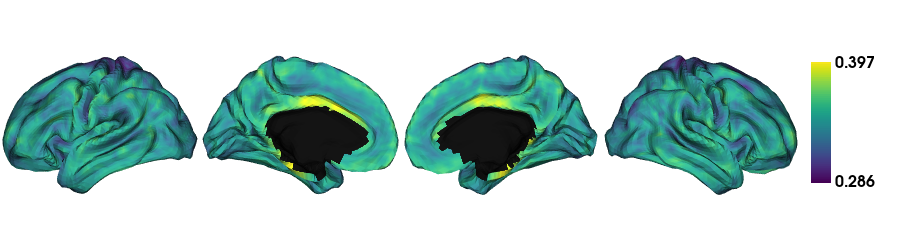

In [68]:
fsLR_5k_parc[mask_5k==False] = np.nan
# Plot average SWM surfaces
plot_hemispheres(f5k_lh, f5k_rh, array_name=fsLR_5k_parc, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False)

In [26]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/AFD_par_average_SWM1mm_fsLR5k.npy', fsLR_5k_parc)

In [31]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/AFD_perpav_average_SWM1mm_fsLR5k.npy', fsLR_5k_parc)

In [36]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/FA_par_average_SWM1mm_fsLR5k.npy', fsLR_5k_parc)

In [41]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/FA_perpav_average_SWM1mm_fsLR5k.npy', fsLR_5k_parc)

In [46]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/MD_par_average_SWM1mm_fsLR5k.npy', fsLR_5k_parc)

In [59]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/MD_perpav_average_SWM1mm_fsLR5k.npy', fsLR_5k_parc)

In [64]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/COMP_par_average_SWM1mm_fsLR5k.npy', fsLR_5k_parc)

In [69]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/COMP_perpav_average_SWM1mm_fsLR5k.npy', fsLR_5k_parc)